In [1]:
import os
import torch
from torch import nn
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import cv2
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from torchvision.transforms.functional import rotate
import random
from skorch import NeuralNetClassifier
import pandas as pd
from time import time
import pickle

rotate_images = False # choose between False, True and random
grayscale = False
resize = 150

In [2]:
# setting up paths 
BASE = os.path.abspath(os.path.join(os.getcwd(), os.pardir))

data_path = os.path.join(BASE, "data")

no_defect = os.listdir(os.path.join(data_path, "KGT_noDefect"))
pitting= os.listdir(os.path.join(data_path, "KGT_pitting"))

<h2> Data exploration </h2>

{(143, 150), (146, 150), (127, 150), (116, 150), (144, 150), (117, 150), (150, 150), (119, 150), (148, 150)}
{'RGB'}


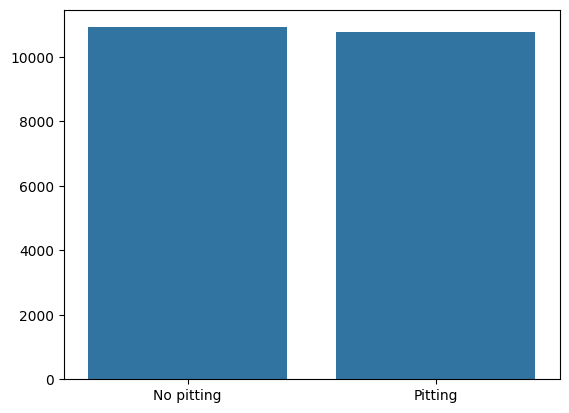

In [7]:
root = os.path.join(BASE, "dataset")
# load the data
dataset = torchvision.datasets.ImageFolder(root=root)
# get the quantity of pitting and no pitting images
number_no_pitting = len(np.where(np.array(dataset.targets) == dataset.class_to_idx["False"])[0])
number_pitting = len(np.where(np.array(dataset.targets) == dataset.class_to_idx["True"])[0])

image_size = set()
image_mode = set()
# loop trough the dataset and 
for image, label in dataset:
    # use sets to only add unique values
    # check image size [width, height]
    image_size.add(image.size)
    # check the type of image e.g. RGB, grayscale
    # on first sight all images  seem to be RGB
    image_mode.add(image.mode)
    
# all images have the same size
print(image_size)
# all images are RGB => 3 channels
print(image_mode)
# plot the number of pitting and no pitting
sns.barplot(x=["No pitting", "Pitting"], y=[number_no_pitting, number_pitting])
plt.show()

<h2> Examine the distribution of the RGB values <h2>

In [ ]:
r_values = []
g_values = []
b_values = []

for i, (img, _) in enumerate(dataset):
    img_np = np.array(img)
    r = img_np[:, :, 0]
    g = img_np[:, :, 1]
    b = img_np[:, :, 2]
    r_values.extend(r.flatten())
    g_values.extend(g.flatten())
    b_values.extend(b.flatten())
    
df = pd.DataFrame({
    'Red': r_values,
    'Green': g_values,
    'Blue': b_values
})

# Count outliers per channel
outlier_counts = {}
for channel in ['Red', 'Green', 'Blue']:
    print(channel)
    q1 = np.percentile(df[channel], 25)
    q3 = np.percentile(df[channel], 75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[channel][(df[channel] < lower) | (df[channel] > upper)]
    outlier_counts[channel] = len(outliers)
    print(f"Q1: {q1}, Q3: {q3}, IQR: {iqr}, max_value: {int(df[channel].max())}, min_value: {int(df[channel].min())}")
    print(f"max_value is outlier for {(int(df[channel].max())-q3)/iqr}")
    print(f"min_value is outlier for {-(int(df[channel].min())-q1)/iqr}")

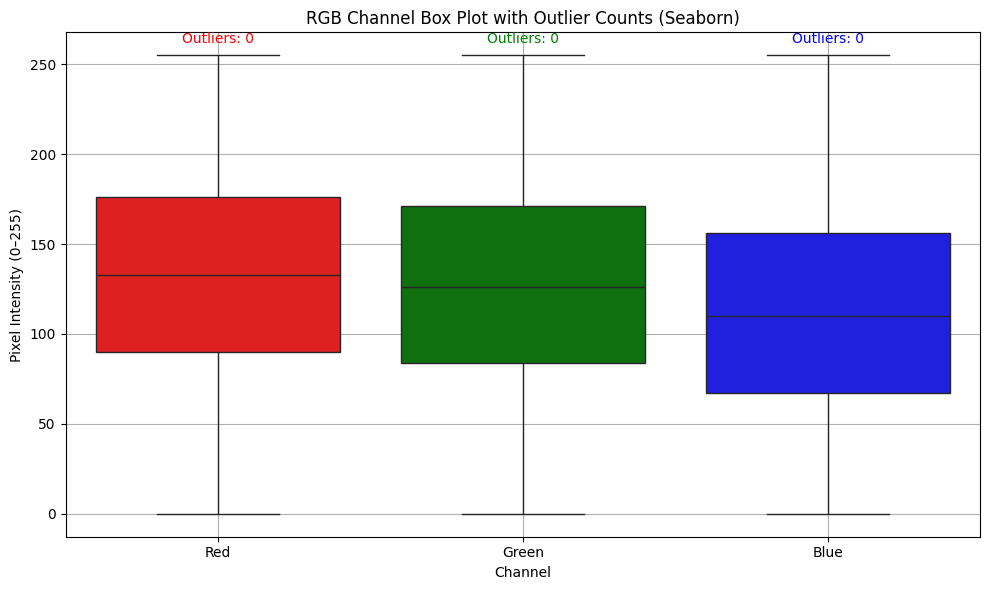

In [6]:
# Melt for Seaborn boxplot
df_melted = df.melt(var_name='Channel', value_name='Intensity')
# Plot with Seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_melted, x='Channel', y='Intensity', hue='Channel', palette={'Red': 'red', 'Green': 'green', 'Blue': 'blue'}, legend=False)
plt.title('RGB Channel Box Plot with Outlier Counts (Seaborn)')
# Annotate outlier counts
for i, channel in enumerate(['Red', 'Green', 'Blue']):
    max_val = int(df[channel].max())
    plt.text(i, max_val + 5, f'Outliers: {outlier_counts[channel]}',
             ha='center', va='bottom', fontsize=10, color=channel.lower())
plt.ylabel('Pixel Intensity (0–255)')
plt.grid(True)
plt.tight_layout()
plt.show()

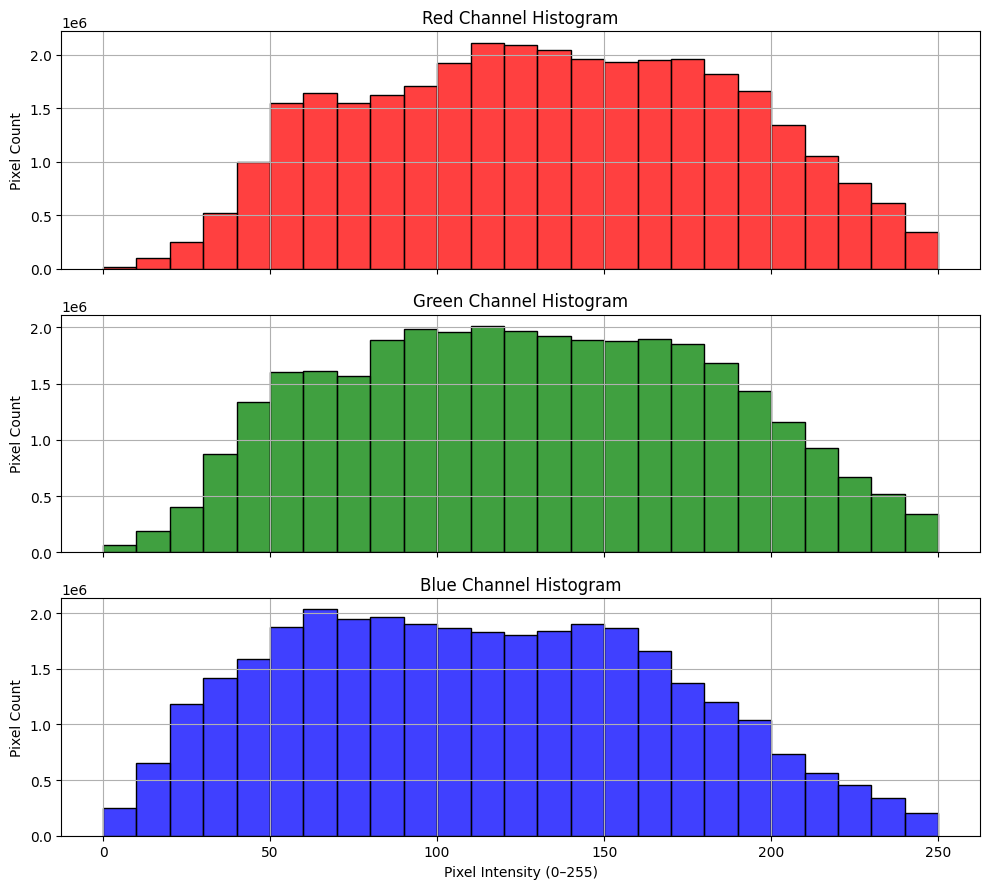

In [8]:
fig, axs = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

channels = ['Red', 'Green', 'Blue']
colors = ['red', 'green', 'blue']
bins = np.arange(0, 257, 10)  # 64 bins

for ax, channel, color in zip(axs, channels, colors):
    sns.histplot(df[channel], bins=bins, color=color, ax=ax)
    ax.set_title(f'{channel} Channel Histogram')
    ax.set_ylabel('Pixel Count')
    ax.grid(True)

axs[-1].set_xlabel('Pixel Intensity (0–255)')
plt.tight_layout()
plt.show()

<h1> Preprocessing </h1>

<h2> Normalize images </h2>

In [4]:
# Training & Validierung 

# Light
train_transform_light = transforms.Compose([
    transforms.Resize(int(resize*1.1)),
    transforms.CenterCrop(resize),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Medium
train_transform_medium = transforms.Compose([
    transforms.Resize(int(resize*1.1)),
    transforms.CenterCrop(resize),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Strong
train_transform_strong = transforms.Compose([
    transforms.Resize(int(resize*1.1)),
    transforms.CenterCrop(resize),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05
    ),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# Test 

# Light
test_transform = transforms.Compose([
    transforms.Resize(int(resize*1.1)),
    transforms.CenterCrop(resize),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
# Datensätze separat laden
def load_full_datasets(transformation: str): 
    transform = {
        "light" : [train_transform_light, test_transform], 
        "medium" : [train_transform_medium, test_transform], 
        "strong" : [train_transform_strong, test_transform]
    }
    full_dataset_train_val = torchvision.datasets.ImageFolder(
        root=root, transform=transform[transformation][0])

    full_dataset_test = torchvision.datasets.ImageFolder(
        root=root, transform=transform[transformation][1])
    
    return full_dataset_train_val, full_dataset_test


In [6]:
full_dataset_train_val_light, full_dataset_test_light = load_full_datasets("light")
full_dataset_train_val_medium, full_dataset_test_medium = load_full_datasets("medium")
full_dataset_train_val_strong, full_dataset_test_strong = load_full_datasets("strong")

In [7]:
def make_split(train_val, test): 
    # Aufteilen
    total_size = len(train_val)
    train_size = int(0.7 * total_size)
    val_size = int(0.15 * total_size)
    test_size = total_size - train_size - val_size

    # Split-Indices
    generator = torch.Generator().manual_seed(42)
    train_val_indices = torch.randperm(total_size, generator=generator)

    # Subsets (verwende die gleichen Indices!)
    train_indices = train_val_indices[:train_size]
    val_indices = train_val_indices[train_size:train_size + val_size]
    test_indices = train_val_indices[train_size + val_size:]

    # Trainings- & Validierungssets mit augmentierten Daten
    train_dataset = torch.utils.data.Subset(train_val, train_indices)
    val_dataset = torch.utils.data.Subset(train_val, val_indices)

    # Testset mit deterministischen Daten
    test_dataset = torch.utils.data.Subset(test, test_indices)

    return train_dataset, val_dataset, test_dataset

In [8]:
train_set_light, val_set_light, test_set_light = make_split(full_dataset_train_val_light, full_dataset_test_light)
train_set_medium, val_set_medium, test_set_medium = make_split(full_dataset_train_val_medium, full_dataset_test_medium)
train_set_strong, val_set_strong, test_set_strong = make_split(full_dataset_train_val_strong, full_dataset_test_strong)

In [9]:
def make_loader(train_set, val_set, test_set): 
    train_loader = DataLoader(train_set, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=16, shuffle=False)
    test_loader = DataLoader(test_set, batch_size=16, shuffle=False)

    return train_loader, val_loader, test_loader

In [10]:
train_loader_light, val_loader_light, test_loader_light = make_loader(train_set_light, val_set_light, test_set_light)
train_loader_medium, val_loader_medium, test_loader_medium = make_loader(train_set_medium, val_set_medium, test_set_medium)
train_loader_strong, val_loader_strong, test_loader_strong = make_loader(train_set_strong, val_set_strong, test_set_strong)

In [11]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 34 * 34, 2048)
        self.fc2 = nn.Linear(2048, 256)
        self.fc3 = nn.Linear(256, 32)
        self.fc4 = nn.Linear(32, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)
        return x



In [12]:
def save_model(model, transformation): 
    torch.save(model.state_dict(), os.path.join(BASE, "models",  f"cnn_pitting_not_simplified_{transformation}.pth"))

def save_metrics(train_losses: list, val_losses: list, train_time, transformation: str): 
    losses = {
        "train_loss": train_losses, 
        "val_loss": val_losses,
        "train_time": train_time
    }

    # path 
    save_path = os.path.join(BASE, "models", f"cnn_metrics_{transformation}.pkl")

    # save
    with open(save_path, "wb") as f:
        pickle.dump(losses, f)

def load_metrics(transformation: str = None): 
    filename = f"cnn_metrics_{transformation}.pkl" if transformation else "metrics.pkl"
    load_path = os.path.join(BASE, "models", filename)

    # Laden
    with open(load_path, "rb") as f:
        metrics = pickle.load(f)
    
    return metrics

def train_model(train_loader, val_loader, transformation: str, device): 
    model = Net()
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    # Training loop with validation
    num_epochs = 3
    train_losses = []
    val_losses = []

    t1 = time() 

    for epoch in range(num_epochs):
        model.train()
        running_train_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        train_losses.append(running_train_loss)

        # Validation loop
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()

        val_losses.append(running_val_loss)

        print(f"Epoch {epoch+1} | Train Loss: {running_train_loss:.4f} | Val Loss: {running_val_loss:.4f}")
    
    t2 = time() 

    train_time = t2 - t1

    save_model(model, transformation)
    save_metrics(train_losses, val_losses, train_time, transformation)

    return model

In [13]:
model_params = {
    "light": [train_loader_light, val_loader_light], 
    "medium": [train_loader_medium, val_loader_medium], 
    "strong": [train_loader_strong, val_loader_strong]
}

trained_models = []
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

for transformation in model_params.keys(): 
    train_loader = model_params[transformation][0]
    val_loader = model_params[transformation][1]
    trained_model = train_model(train_loader, val_loader, transformation, device)
    trained_models.append(trained_model)
    

Using mps device
Epoch 1 | Train Loss: 26.2555 | Val Loss: 4.9526
Epoch 2 | Train Loss: 15.5672 | Val Loss: 3.3149
Epoch 3 | Train Loss: 10.5266 | Val Loss: 3.8992
Epoch 1 | Train Loss: 28.0901 | Val Loss: 4.7877
Epoch 2 | Train Loss: 17.6088 | Val Loss: 5.4253
Epoch 3 | Train Loss: 15.8523 | Val Loss: 3.3770
Epoch 1 | Train Loss: 31.2406 | Val Loss: 4.8743
Epoch 2 | Train Loss: 18.7581 | Val Loss: 4.4151
Epoch 3 | Train Loss: 16.6678 | Val Loss: 3.6286


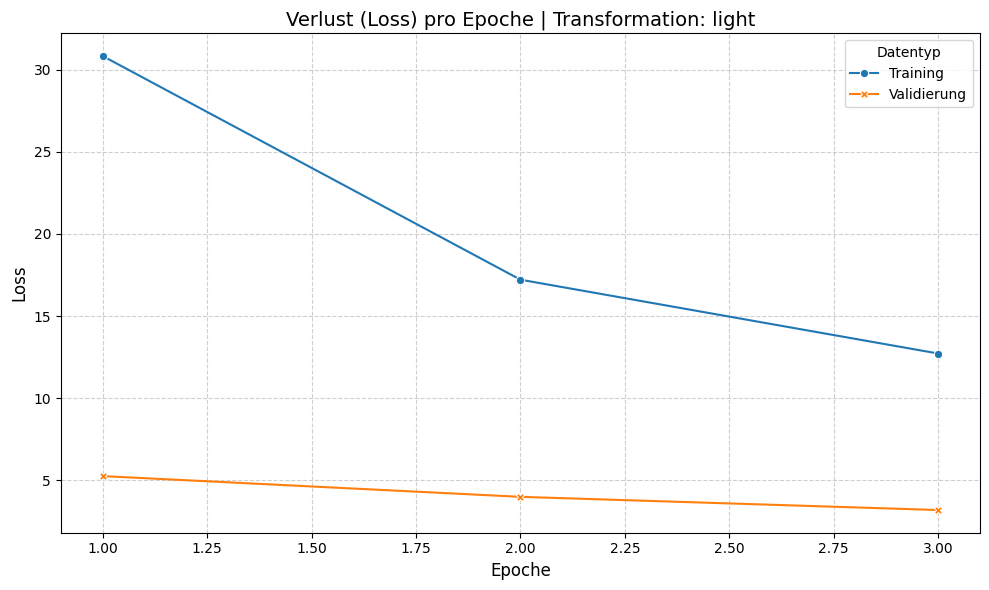

In [15]:
def plot_losses(losses, transformation):
    epochs = list(range(1, len(losses["train_loss"]) + 1))
    
    df = pd.DataFrame({
        "Epoche": epochs * 2,
        "Loss": losses["train_loss"] + losses["val_loss"],
        "Typ": ["Training"] * len(epochs) + ["Validierung"] * len(epochs)
    })
    
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=df, x="Epoche", y="Loss", hue="Typ", style="Typ", markers=True, dashes=False)

    plt.title(f"Verlust (Loss) pro Epoche | Transformation: {transformation}", fontsize=14)
    plt.xlabel("Epoche", fontsize=12)
    plt.ylabel("Loss", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(title="Datentyp", loc="upper right")
    plt.tight_layout()
    plt.show()
losses = load_metrics("light")
testfig = plot_losses(losses, "light")

In [16]:
#load model
def load_model(transformation: str = None): 
    model = Net()
    filename = f"cnn_pitting_not_simplified_{transformation}.pth" if transformation else "cnn_pitting_not_simplified.pth"
    load_path = os.path.join(BASE, "models", filename)
    model.load_state_dict(torch.load(load_path))
    device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
    model.to(device) 
    return model 
light_model = load_model("light")
medium_model = load_model("medium")
strong_model = load_model("strong")

In [17]:
time_light = load_metrics("light")["train_time"] /60
time_medium = load_metrics("medium")["train_time"] /60
time_strong = load_metrics("strong")["train_time"] /60

print(time_light, time_medium, time_strong)

0.3149001638094584 0.23210703531901042 0.29054808219273887


In [18]:
def test_model(model, test_loader, class_names=None, return_metrics=False):

    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # metrics
    acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, digits=4)

    print(f"Test Accuracy: {acc:.4f}")
    print("\n Classification Report:")
    print(report)

    # Confusion matrix 
    plt.figure(figsize=(8, 6))
    try: 
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names)
    except: 
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Vorhergesagte Klasse")
    plt.ylabel("Wahre Klasse")
    plt.title("Konfusionsmatrix")
    plt.tight_layout()
    plt.show()

    if return_metrics:
        return acc, cm, report

Test Accuracy: 0.9111

 Classification Report:
              precision    recall  f1-score   support

           0     0.8936    0.8936    0.8936        94
           1     0.9237    0.9237    0.9237       131

    accuracy                         0.9111       225
   macro avg     0.9086    0.9086    0.9086       225
weighted avg     0.9111    0.9111    0.9111       225



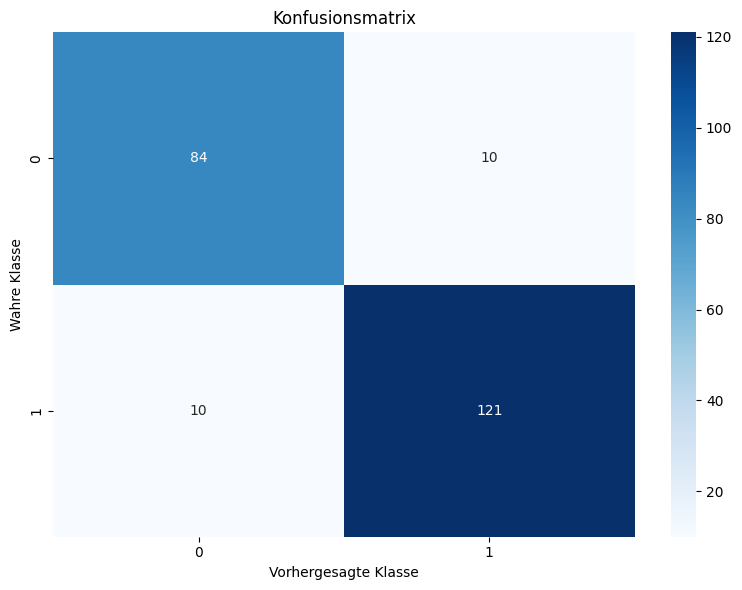

In [19]:
test_model(light_model, test_loader_light)

Test Accuracy: 0.9333

 Classification Report:
              precision    recall  f1-score   support

           0     0.9072    0.9362    0.9215        94
           1     0.9531    0.9313    0.9421       131

    accuracy                         0.9333       225
   macro avg     0.9302    0.9337    0.9318       225
weighted avg     0.9339    0.9333    0.9335       225



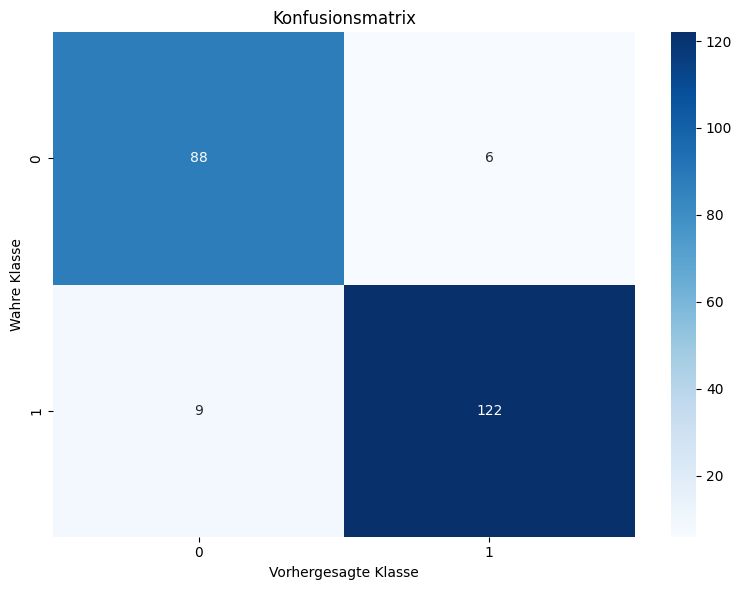

In [20]:
test_model(medium_model, test_loader_medium)

Test Accuracy: 0.9333

 Classification Report:
              precision    recall  f1-score   support

           0     0.9877    0.8511    0.9143        94
           1     0.9028    0.9924    0.9455       131

    accuracy                         0.9333       225
   macro avg     0.9452    0.9217    0.9299       225
weighted avg     0.9382    0.9333    0.9324       225



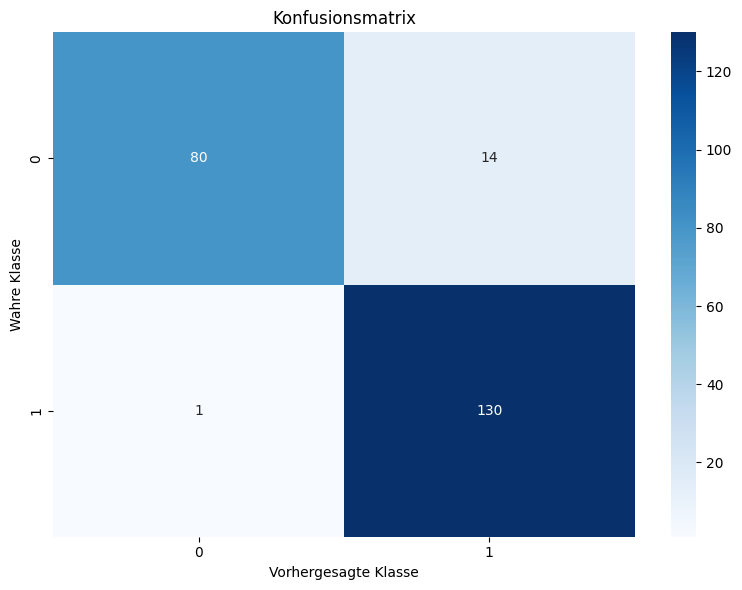

In [21]:
test_model(strong_model, test_loader_strong)

In [12]:
outputs = net(images)
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(len(images))))

Predicted:  True  True  True  True  True  False True  False False True  True  False True  True  True  False True  False False True  True  True  False True  False False False False True  False True  True 


Accuracy: 0.9098
Precision: 0.9184
Recall:    0.9184
F1 Score:  0.9184


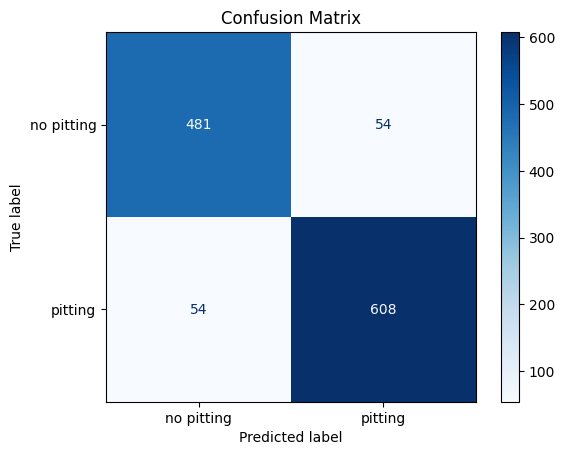

In [13]:
correct = 0
total = 0
all_preds = []
all_labels = []
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in test_loader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = correct / total
cm = confusion_matrix(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='binary')
recall = recall_score(all_labels, all_preds, average='binary')
f1 = f1_score(all_labels, all_preds, average='binary')
print(f"Accuracy: {accuracy:.4f}")
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1 Score:  {f1:.4f}')

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no pitting", "pitting"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

<h2> GridSearchCV </h2>

In [14]:
X_train_list = []
y_train_list = []
for i in range(len(train_dataset)):
    data, label = train_dataset[i]
    X_train_list.append(data.numpy()) # Convert to NumPy array
    y_train_list.append(label) # Convert to NumPy array

X_train = np.array(X_train_list).astype(np.float32)
y_train = np.array(y_train_list).astype(np.int64)

# For test data
X_test_list = []
y_test_list = []
for i in range(len(test_dataset)):
    data, label = test_dataset[i]
    X_test_list.append(data.numpy())
    y_test_list.append(label)

X_test = np.array(X_test_list).astype(np.float32)
y_test = np.array(y_test_list).astype(np.int64)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")



net = NeuralNetClassifier(Net(), criterion=criterion, optimizer=optim.SGD, max_epochs=10, lr=0.01)

param_grid = {
    'lr': [0.01, 0.1],
    'max_epochs': [2, 3],
    #'module__dropout': [0.0, 0.2],
    'batch_size': [32],
}

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',       
    'f1': 'f1',               
}

grid_search = GridSearchCV(estimator=net, param_grid=param_grid, cv=StratifiedKFold(n_splits=5), scoring=scoring, refit="accuracy", n_jobs=-1, verbose=3)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n--- Best Parameters and Score ---")
print("Best parameters found: ", grid_search.best_params_)
print("Best accuracy on cross-validation set: ", grid_search.best_score_)

print("\n--- Evaluation on Test Set (using the best model) ---")
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='macro') # Use 'macro' for multi-class, or 'binary' for binary
recall = recall_score(y_test, y_pred, average='macro')     # Use 'macro' for multi-class, or 'binary' for binary
f1 = f1_score(y_test, y_pred, average='macro')             # Use 'macro' for multi-class, or 'binary' for binary

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

X_train shape: (1271, 3, 150, 150), y_train shape: (1271,)
X_test shape: (225, 3, 150, 150), y_test shape: (225,)
Fitting 5 folds for each of 4 candidates, totalling 20 fits
  epoch    train_loss    valid_acc    valid_loss      dur
-------  ------------  -----------  ------------  -------
      1        0.7049       0.4265        0.6942  20.9017
  epoch    train_loss    valid_acc    valid_loss      dur
-------  ------------  -----------  ------------  -------
      1        0.7052       0.4265        0.6945  21.1580
  epoch    train_loss    valid_acc    valid_loss      dur
-------  ------------  -----------  ------------  -------
      1        0.7049       0.4265        0.6955  21.2195
  epoch    train_loss    valid_acc    valid_loss      dur
-------  ------------  -----------  ------------  -------
      1        0.7047       0.4265        0.6939  21.4341
  epoch    train_loss    valid_acc    valid_loss      dur
-------  ------------  -----------  ------------  -------
      1       

In [16]:
print("\n--- Detailed Cross-Validation Results  ---")
results = grid_search.cv_results_
# Sort by the refit metric (accuracy in this case)
sorted_indices = np.argsort(results['rank_test_accuracy'])
for i in sorted_indices:
    print(f"Rank {results['rank_test_accuracy'][i]}:")
    print(f"  Params: {results['params'][i]}")
    print(f"  Mean Accuracy: {results['mean_test_accuracy'][i]:.4f} (std: {results['std_test_accuracy'][i]:.4f})")
    print(f"  Mean Precision: {results['mean_test_precision'][i]:.4f} (std: {results['std_test_precision'][i]:.4f})")
    print(f"  Mean Recall: {results['mean_test_recall'][i]:.4f} (std: {results['std_test_recall'][i]:.4f})")
    print(f"  Mean F1-score: {results['mean_test_f1'][i]:.4f} (std: {results['std_test_f1'][i]:.4f})")
    print("-" * 30)


--- Detailed Cross-Validation Results  ---
Rank 1:
  Params: {'batch_size': 32, 'lr': 0.01, 'max_epochs': 2}
  Mean Accuracy: 0.8308 (std: 0.0301)
  Mean Precision: 0.8258 (std: 0.0281)
  Mean Recall: 0.8976 (std: 0.0593)
  Mean F1-score: 0.8587 (std: 0.0285)
------------------------------
Rank 2:
  Params: {'batch_size': 32, 'lr': 0.1, 'max_epochs': 2}
  Mean Accuracy: 0.8096 (std: 0.0645)
  Mean Precision: 0.8985 (std: 0.0374)
  Mean Recall: 0.7639 (std: 0.1520)
  Mean F1-score: 0.8125 (std: 0.0932)
------------------------------
Rank 3:
  Params: {'batch_size': 32, 'lr': 0.1, 'max_epochs': 3}
  Mean Accuracy: 0.7325 (std: 0.1463)
  Mean Precision: 0.9279 (std: 0.0448)
  Mean Recall: 0.5978 (std: 0.2913)
  Mean F1-score: 0.6661 (std: 0.2792)
------------------------------
Rank 4:
  Params: {'batch_size': 32, 'lr': 0.01, 'max_epochs': 3}
  Mean Accuracy: 0.6837 (std: 0.0403)
  Mean Precision: 0.6498 (std: 0.0360)
  Mean Recall: 0.9891 (std: 0.0153)
  Mean F1-score: 0.7834 (std: 0.020

<h1> Appendix/ old Code </h1>

In [ ]:
"""def transform_images(angle=None, grayscale=False):
    # set up a pipeline for normalization
    # first all pixel values are scaled to [0.0, 1.0] and then normalized with x_new = (x-mean) / std where mean is the first tuple
    # and std is the second tuple for each of the 3 channels
    # if an angle is given the image is rotated by angle degrees
    if angle and grayscale:
        transform = transforms.Compose([
            transforms.Lambda(lambda img: rotate(img, angle=angle)),
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))])
    elif angle:
        transform = transforms.Compose([
            transforms.Lambda(lambda img: rotate(img, angle=angle)),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
    elif grayscale:
        transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,))])
    else:
        transform = transforms.Compose(
            [transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
    return torchvision.datasets.ImageFolder(root=root, transform=transform)

batch_size = 32
# load and normalize the data
dataset = transform_images(grayscale=grayscale)

if rotate_images == True:
    dataset_rotated_90 = transform_images(angle=90, grayscale=grayscale)
    dataset_rotated_180 = transform_images(angle=180, grayscale=grayscale)
    dataset_rotated_270 = transform_images(angle=270, grayscale=grayscale)
    dataset = torch.utils.data.ConcatDataset([dataset, dataset_rotated_90, dataset_rotated_180, dataset_rotated_270])
elif rotate_images == "random":
    dataset_rotated_90 = transform_images(angle=random.uniform(1.00, 359.0), grayscale=grayscale)
    dataset_rotated_180 = transform_images(angle=random.uniform(1.00, 359.0), grayscale=grayscale)
    dataset_rotated_270 = transform_images(angle=random.uniform(1.00, 359.0), grayscale=grayscale)
    dataset = torch.utils.data.ConcatDataset([dataset, dataset_rotated_90, dataset_rotated_180, dataset_rotated_270])

# do a train test split with 80% train size
train_size = int(0.85 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset=dataset, lengths=[train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
# False=no pitting, True=pitting
classes = ("False", "True")

for epoch in range(10):  # loop over the dataset multiple times
    print(f"epoch {epoch}")
    running_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

images, labels = next(iter(test_loader))

# Make grid (tensor) from images
img_grid = torchvision.utils.make_grid(images)

# Convert tensor to numpy and rearrange axes for matplotlib (H, W, C)
npimg = img_grid.numpy().transpose((1, 2, 0))

# Unnormalize (reverse the normalization you applied)
mean = [0.5, 0.5, 0.5]
std = [0.5, 0.5, 0.5]
npimg = std * npimg + mean

# Clip values to valid range
npimg = np.clip(npimg, 0, 1)

plt.imshow(npimg)
plt.axis('off')
plt.show()

print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(len(images))))

"""